In [1]:
#| default_exp pymor.vectorarrays

In [2]:
%%capture
%load_ext autoreload
%autoreload 2

# pymor.vectorarrays

> Extended functionality for [pyMOR](https://pymor.org/) vector arrays

## Imports -

In [3]:
#| hide
from fastcore.test import test_close, test_eq
from nbdev.showdoc import show_doc

from pylgs.utilities.testing import test_da

In [4]:
#| export
from numbers import Number, Real
from functools import partial
import inspect
from typing import Optional

from fastcore.basics import patch, first
from fastcore.meta import delegates

import numpy as np
from numpy import array, ndarray
import xarray as xr
from xarray import DataArray, Variable
from pymor.basic import NumpyVectorSpace
from pymor.core.base import classinstancemethod
from pymor.vectorarrays.interface import VectorArray, VectorArrayImpl, VectorSpace

from pylgs.utilities.basic import get_item, filter_args, filter_out_args
from pylgs.utilities.xarray import Coordinates
from pylgs.utilities.formatting import prefix_format

In [5]:
#|export
import pandas as pd
import plotly.express as px
import plotly

In [6]:
#|hide
test_da = partial(test_da, 'test_data/vectorarrays', update='allow')

## XarrayVectorSpace

### XarrayVectorArrayImpl -

In [7]:
#| export
#|hide
class XarrayVectorArrayImpl(VectorArrayImpl):

    def __init__(self, _array, space_array):
        self.dims = tuple(set(_array.dims) - set(space_array.dims))
        self.__auto_init(locals())

    @property
    def array(self): return self._array

    @property
    def coords(self): return self._array.coords

    @property
    def _len(self): return self._array.size // self.space_array.size
    
    def __len__(self): return self._len

    def copy(self, deep, ind):
        new_array = self._array if ind is None else self._array[ind].copy()
        return XarrayVectorArrayImpl(new_array, self.space_array)

    @property
    def extended_dims(self):
        return tuple(dim for dim in self._array.dims if dim not in self.space_array.dims)
    
    def to_numpy(self, ensure_copy, ind): raise NotImplementedError
    def real(self, ind): raise NotImplementedError
    def imag(self, ind): raise NotImplementedError
    def conj(self, ind): raise NotImplementedError
    def delete(self, ind): raise NotImplementedError
    def append(self, other, remove_from_other, oind): raise NotImplementedError
    def scal(self, alpha, ind): raise NotImplementedError
    def scal_copy(self, alpha, ind): raise NotImplementedError
    def axpy(self, alpha, x, ind, xind): raise NotImplementedError
    def axpy_copy(self, alpha, x, ind, xind): raise NotImplementedError
    def inner(self, other, ind, oind): raise NotImplementedError
    def pairwise_inner(self, other, ind, oind): raise NotImplementedError
    def lincomb(self, coefficients, ind): raise NotImplementedError
    def norm(self, ind): raise NotImplementedError
    def norm2(self, ind): raise NotImplementedError
    def dofs(self, dof_indices, ind): raise NotImplementedError
    def amax(self, ind): raise NotImplementedError

In [8]:
#| export
#|hide
def _abbreviate(s):
    s = s.split('(')[0]
    words = s.split()
    if len(words) > 1: return ''.join(w[0].capitalize() for w in words)
    return s[:2]

In [9]:
#| export
#|hide
def _coords_str(coords, dims=None):
    if not coords: return '{1}'
    if dims is None: dims = list(coords)
    return '{' + ' ⨉ '.join(f'{dim}({len(coords[dim])})' for dim in dims) + '}'

In [10]:
#| export
def _short_coords_str(coords, dims=None):
    if not coords: return '{1}'
    if dims is None: dims = list(coords)
    return '{' + ' ⨉ '.join(f'{_abbreviate(dim)}({len(coords[dim])})' for dim in dims) + '}'

### XarrayVectorArray -

In [11]:
#| export
#|hide
class XarrayVectorArray(VectorArray):
    """`VectorArray` implementation via xarray arrays."""

    impl_type = XarrayVectorArrayImpl

    @property
    def array(self): return self.impl.array

    @property
    def shape(self): return self.array.shape
    
    @property
    def coords(self): return self.impl.coords

    @property
    def dims(self): return self.impl.space_array.dims
    
    @property
    def extended_dims(self): return self.impl.extended_dims

    def _coords_str(self, dims):
        if not dims: return '{1}'
        sizes = self.array.sizes
        return '{' + ' ⨉ '.join(f'{dim}({sizes[dim]})' for dim in dims) + '}'        
    
    def __str__(self):
        return self._coords_str(self.dims)[:-1] + ", " + self._coords_str(self.extended_dims)[1:]
    
    def short_str(self):
        return _short_coords_str(self.space)[:-1] + ", " + _short_coords_str(self.coords, self.extended_dims)[1:]
    
    def _repr_html_(self):
        return str(self)

### XarrayVectorSpace -

In [12]:
#| export
class XarrayVectorSpace(VectorSpace):
    """`VectorSpace` of `XarrayVectorArrays`."""

    def __init__(
        self, 
        coords:Optional[Coordinates|dict|DataArray]=None, 
        name:Optional[str]=None, 
        attrs:Optional[dict]=None, 
        id=None      # See `~pymor.vectorarrays.interface.VectorSpace.id`.
    ):
        if isinstance(coords, dict):
            coords = Coordinates(coords)
        elif isinstance(coords, DataArray):
            if name is None: name = coords.name
            coords = Coordinates({dim: coords[dim] for dim in coords.dims})
        # elif isinstance(coords, list):
        #     coords = Coordinates({c.name: c.data for c in coords}) *** Do we need list input?        
        self._array = DataArray(np.zeros(coords.shape if coords is not None else ()), coords=coords, name=name, attrs=attrs) 

        self.dims = self._array.dims
        self.__auto_init(locals())

    @property
    def dim(self): return self._array.size

    @property
    def shape(self): return self._array.shape
    
    @classinstancemethod
    def make_array(cls, obj, id=None):
        vec = cls._array_factory(obj, id=id)
        vec.name = obj.name
        return vec

    @make_array.instancemethod
    def make_array(self, obj):
        """:noindex:""" 
        vec = self._array_factory(obj, space=self)
        vec.name = obj.name
        return vec        

    @classmethod
    def _array_factory(cls, array:DataArray, space):
        return XarrayVectorArray(space, XarrayVectorArrayImpl(array, space._array))

    def zeros(
        self, 
        coords:Optional[dict]=None, # Coordinates to extend vector space over
        reserve=0
    )->XarrayVectorArray: # `XarrayVectorArray` with all elements equal to zero
        """Return `XarrayVectorArray` of null vectors in XarrayVectorSpace optionally extended to include supplied coordinates `coords`."""
        if coords is None: coords = {}
        array = xr.zeros_like(self._array.expand_dims(coords))
        return self._array_factory(array, space=self)

    def ones(
        self, 
        coords:Optional[dict]=None, # Coordinates to extend vector space over
        reserve=0
    )->XarrayVectorArray: # `XarrayVectorArray` with all elements equal to one
        """Return `XarrayVectorArray` of vectors with each element equal to one in XarrayVectorSpace optionally extended to include supplied coordinates `coords`."""
        if coords is None: coords = {}
        array = xr.ones_like(self._array.expand_dims(coords))
        return self._array_factory(array, space=self)

    def __str__(self):
        return _coords_str(self.coords)

    def short_str(self):
        return _short_coords_str(self.coords)
    
    def _repr_html_(self):
        return str(self)

    def __hash__(self):
        return hash(self.dim)

"Empty" `XarrayVectorSpace` with no coordinates (used, for example, for operators whose range is a scalar):

In [13]:
space1 = XarrayVectorSpace()
space1

XarrayVectorSpace()

In [14]:
#|hide
test_eq(_.dim, 1)
test_eq(_.shape, ())
test_eq(_.dims, ())
test_eq(_.name, 'XarrayVectorSpace')

`XarrayVectorSpace` from dictionary of coordinates:

In [15]:
coords = {'foo': [1, 2, 3], 'bar': ['a', 'b']}
space2 = XarrayVectorSpace(coords)
space2

XarrayVectorSpace(
    coords=Coordinates:
             * foo      (foo) int64 24B 1 2 3
             * bar      (bar) <U1 8B 'a' 'b')

In [16]:
#|hide
test_eq(_.shape, (3, 2))
test_eq(_.dims, ('foo', 'bar'))
test_eq(_.name, 'XarrayVectorSpace')

From xarray `Coordinates`:

In [17]:
coords = Coordinates(coords)
XarrayVectorSpace(coords)

XarrayVectorSpace(
    coords=Coordinates:
             * foo      (foo) int64 24B 1 2 3
             * bar      (bar) <U1 8B 'a' 'b')

In [18]:
#|hide
test_eq(_.shape, (3, 2))
test_eq(_.dims, ('foo', 'bar'))
test_eq(_.name, 'XarrayVectorSpace')

From `DataArray` with default dimensions and coordinates:

In [19]:
da = DataArray(np.ones(coords.shape))
space3 = XarrayVectorSpace(da)
space3

XarrayVectorSpace(
    coords=Coordinates:
             * dim_0    (dim_0) int64 24B 0 1 2
             * dim_1    (dim_1) int64 16B 0 1)

In [20]:
#|hide
test_eq(_.shape, (3, 2))
test_eq(_.dims, ('dim_0', 'dim_1'))
test_eq(_.name, 'XarrayVectorSpace')

From `DataArray`:

In [21]:
da = DataArray(np.ones(coords.shape), coords=coords, name='baz')
space = XarrayVectorSpace(da)
space

XarrayVectorSpace(
    coords=Coordinates:
             * foo      (foo) int64 24B 1 2 3
             * bar      (bar) <U1 8B 'a' 'b',
    name='baz')

In [22]:
#|hide
test_eq(_.shape, (3, 2))
test_eq(_.dims, ('foo', 'bar'))
test_eq(_.name, 'baz')

In [23]:
show_doc(XarrayVectorSpace.zeros)

---

[source](https://github.com/simonkeys/pylgs/blob/main/pylgs/pymor/vectorarrays.py#L178){target="_blank" style="float:right; font-size:smaller"}

### XarrayVectorSpace.zeros

>      XarrayVectorSpace.zeros (coords:Optional[dict]=None, reserve=0)

*Return `XarrayVectorArray` of null vectors in XarrayVectorSpace optionally extended to include supplied coordinates `coords`.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| coords | Optional | None | Coordinates to extend vector space over |
| reserve | int | 0 |  |
| **Returns** | **XarrayVectorArray** |  | **`XarrayVectorArray` with all elements equal to zero** |

In [24]:
U = space.zeros()
U

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * foo      (foo) int64 24B 1 2 3
                 * bar      (bar) <U1 8B 'a' 'b',
        name='baz'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
        array([[0., 0.],
               [0., 0.],
               [0., 0.]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b',
        <xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
        array([[0., 0.],
               [0., 0.],
               [0., 0.]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b'),
    _len=1)

In [25]:
U.array

<xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
array([[0., 0.],
       [0., 0.],
       [0., 0.]])
Coordinates:
  * foo      (foo) int64 24B 1 2 3
  * bar      (bar) <U1 8B 'a' 'b'

In [26]:
#|hide
test_da('zeros1', _)

In [27]:
U = space.zeros({'bam': [.2, .3, .4]})
U

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * foo      (foo) int64 24B 1 2 3
                 * bar      (bar) <U1 8B 'a' 'b',
        name='baz'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'baz' (bam: 3, foo: 3, bar: 2)> Size: 144B
        array([[[0., 0.],
                [0., 0.],
                [0., 0.]],

               [[0., 0.],
                [0., 0.],
                [0., 0.]],

               [[0., 0.],
                [0., 0.],
                [0., 0.]]])
        Coordinates:
          * bam      (bam) float64 24B 0.2 0.3 0.4
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b',
        <xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
        array([[0., 0.],
               [0., 0.],
               [0., 0.]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b'),
    _len=3)

In [28]:
#|hide
test_da('zeros2', _.array)

In [29]:
U.dim

6

In [30]:
len(U)

3

This is effectively a generalization of a `NumpyVectorArray`:

In [31]:
NumpyVectorSpace(6).zeros()

NumpyVectorArray(
    NumpyVectorSpace(6),
    [[0.]
     [0.]
     [0.]
     [0.]
     [0.]
     [0.]],
    _len=1)

In [32]:
U_np = NumpyVectorSpace(6).zeros(3)

In [33]:
U_np.dim

6

In [34]:
len(U_np)

3

In [35]:
show_doc(XarrayVectorSpace.ones)

---

[source](https://github.com/simonkeys/pylgs/blob/main/pylgs/pymor/vectorarrays.py#L187){target="_blank" style="float:right; font-size:smaller"}

### XarrayVectorSpace.ones

>      XarrayVectorSpace.ones (coords:Optional[dict]=None, reserve=0)

*Return `XarrayVectorArray` of vectors with each element equal to one in XarrayVectorSpace optionally extended to include supplied coordinates `coords`.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| coords | Optional | None | Coordinates to extend vector space over |
| reserve | int | 0 |  |
| **Returns** | **XarrayVectorArray** |  | **`XarrayVectorArray` with all elements equal to one** |

In [36]:
U = space.ones()
U

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * foo      (foo) int64 24B 1 2 3
                 * bar      (bar) <U1 8B 'a' 'b',
        name='baz'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
        array([[1., 1.],
               [1., 1.],
               [1., 1.]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b',
        <xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
        array([[0., 0.],
               [0., 0.],
               [0., 0.]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b'),
    _len=1)

In [37]:
U.array

<xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
array([[1., 1.],
       [1., 1.],
       [1., 1.]])
Coordinates:
  * foo      (foo) int64 24B 1 2 3
  * bar      (bar) <U1 8B 'a' 'b'

In [38]:
#|hide
test_da('ones1', _)

In [39]:
space.ones({'bam': [.2, .3, .4]})

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * foo      (foo) int64 24B 1 2 3
                 * bar      (bar) <U1 8B 'a' 'b',
        name='baz'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'baz' (bam: 3, foo: 3, bar: 2)> Size: 144B
        array([[[1., 1.],
                [1., 1.],
                [1., 1.]],

               [[1., 1.],
                [1., 1.],
                [1., 1.]],

               [[1., 1.],
                [1., 1.],
                [1., 1.]]])
        Coordinates:
          * bam      (bam) float64 24B 0.2 0.3 0.4
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b',
        <xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
        array([[0., 0.],
               [0., 0.],
               [0., 0.]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b'),
    _len=3)

In [40]:
#|hide
test_da('ones2', _.array)

### random -

In [41]:
#| export
from pymor.vectorarrays.interface import _create_random_values

In [42]:
#| export
@patch
def random(
    self:XarrayVectorSpace, 
    coords=None, 
    distribution='uniform', 
    name=None
)->XarrayVectorArray: # A random `XarrayVectorArray` in the vector space
    array = self._array.expand_dims(coords)
    if name is not None: array = array.rename(name)
    values = _create_random_values(array.shape, distribution)
    array.data = values
    return self.make_array(array)

In [43]:
space.random().array

<xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
array([[0.77395605, 0.69736803],
       [0.43887844, 0.09417735],
       [0.85859792, 0.97562235]])
Coordinates:
  * foo      (foo) int64 24B 1 2 3
  * bar      (bar) <U1 8B 'a' 'b'

In [44]:
space.random({'bam': [1, 2, 3]}).array

<xarray.DataArray 'baz' (bam: 3, foo: 3, bar: 2)> Size: 144B
array([[[0.7611397 , 0.22723872],
        [0.45038594, 0.82763117],
        [0.64386512, 0.35452597]],

       [[0.78606431, 0.55458479],
        [0.37079802, 0.6316644 ],
        [0.82276161, 0.97069802]],

       [[0.12811363, 0.06381726],
        [0.92676499, 0.75808774],
        [0.4434142 , 0.89312112]]])
Coordinates:
  * bam      (bam) int64 24B 1 2 3
  * foo      (foo) int64 24B 1 2 3
  * bar      (bar) <U1 8B 'a' 'b'

In [45]:
space.random().name

'baz'

In [46]:
space.random(name='boo').name

'boo'

### ndim -


In [47]:
#| export
@patch(as_prop=True)
def ndim(self:XarrayVectorSpace): 
    """Number of dimensions of the vector space."""
    return self._array.ndim

In [48]:
space.ndim

2

In [49]:
#|hide
test_eq(_, 2)

In [50]:
# #| export
# @patch(as_prop=True)
# def ndim(self:XarrayVectorArray): return self.array.ndim

### from_xarray -

In [51]:
#| export
@patch
def from_xarray(
    self:XarrayVectorSpace, 
    data:DataArray
)->XarrayVectorArray:
    """Return an `XarrayVectorArray` containing data from `DataArray` `data`."""
    return self.make_array(data)

A `DataArray` with the same coordinates as `space`:

In [52]:
da = space.random().array
da

<xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
array([[0.12992151, 0.66981399],
       [0.47570493, 0.43715192],
       [0.22690935, 0.8326782 ]])
Coordinates:
  * foo      (foo) int64 24B 1 2 3
  * bar      (bar) <U1 8B 'a' 'b'

An `XarrayVectorArray` in `space` with data from `da`:

In [53]:
space.from_xarray(da)

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * foo      (foo) int64 24B 1 2 3
                 * bar      (bar) <U1 8B 'a' 'b',
        name='baz'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
        array([[0.12992151, 0.66981399],
               [0.47570493, 0.43715192],
               [0.22690935, 0.8326782 ]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b',
        <xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
        array([[0., 0.],
               [0., 0.],
               [0., 0.]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b'),
    _len=1)

An `XarrayVectorArray` from an array in `space` plus extended dimensions:

In [54]:
space.from_xarray(space.random({'bam': [1, 2, 3]}).array)

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * foo      (foo) int64 24B 1 2 3
                 * bar      (bar) <U1 8B 'a' 'b',
        name='baz'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'baz' (bam: 3, foo: 3, bar: 2)> Size: 144B
        array([[[0.7002651 , 0.00736227],
                [0.80476436, 0.70516538],
                [0.6824955 , 0.5687412 ]],

               [[0.31236664, 0.78692438],
                [0.38747838, 0.78072903],
                [0.13975248, 0.139797  ]],

               [[0.8322598 , 0.66485086],
                [0.2883281 , 0.45891578],
                [0.1999082 , 0.11453007]]])
        Coordinates:
          * bam      (bam) int64 24B 1 2 3
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b',
        <xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
        array([[0., 0.],
               [0., 0.],
               [0., 0.]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b'),
    _len=3)

### from_numpy -


In [55]:
#| export
@patch
def from_numpy(
    self:XarrayVectorSpace, 
    data:ndarray, 
    coords=None, 
    extended_dim=None, 
    id=None, 
    ensure_copy=False
)->XarrayVectorArray: # A vector array with data from the numpy array
    """Return an `XarrayVectorArray` in the vector space with data from the `ndarray` `data`."""
    if ensure_copy: data = data.copy()
    if data.size == self.dim and extended_dim is None:
        shape = self.shape
        coords = self.coords
        dims = self.dims
    else:
        if coords is None:
            if extended_dim is None: extended_dim = 'len'
            if isinstance(extended_dim, str):
                extended_dim = {extended_dim: np.arange(data.size // self.dim)}
            coords = self.coords.copy()
            coords.update(extended_dim)
            dims = list(extended_dim) + list(self.dims)
            shape = [len(coords[dim]) for dim in dims]
        else: 
            coords = Coordinates(coords)
            dims = coords.dims
            shape = coords.shape
    array = DataArray(
        data.reshape(shape),
        coords=coords,
        dims=dims,
        attrs=self._array.attrs
    )
    return self._array_factory(array, space=self)

In [56]:
space.from_numpy(np.random.rand(space.dim * 2))

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * foo      (foo) int64 24B 1 2 3
                 * bar      (bar) <U1 8B 'a' 'b',
        name='baz'),
    XarrayVectorArrayImpl(
        <xarray.DataArray (len: 2, foo: 3, bar: 2)> Size: 96B
        array([[[0.24226113, 0.76455152],
                [0.2374083 , 0.25364652],
                [0.37657013, 0.769482  ]],

               [[0.99544639, 0.96895668],
                [0.09241663, 0.81633569],
                [0.95061696, 0.11358402]]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b'
          * len      (len) int64 16B 0 1,
        <xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
        array([[0., 0.],
               [0., 0.],
               [0., 0.]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b'),
    _len=2)

In [57]:
_.array

<xarray.DataArray (len: 2, foo: 3, bar: 2)> Size: 96B
array([[[0.24226113, 0.76455152],
        [0.2374083 , 0.25364652],
        [0.37657013, 0.769482  ]],

       [[0.99544639, 0.96895668],
        [0.09241663, 0.81633569],
        [0.95061696, 0.11358402]]])
Coordinates:
  * foo      (foo) int64 24B 1 2 3
  * bar      (bar) <U1 8B 'a' 'b'
  * len      (len) int64 16B 0 1

In [58]:
space.from_numpy(np.random.rand(space.dim * 2), extended_dim={'time': [5, 7]})

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * foo      (foo) int64 24B 1 2 3
                 * bar      (bar) <U1 8B 'a' 'b',
        name='baz'),
    XarrayVectorArrayImpl(
        <xarray.DataArray (time: 2, foo: 3, bar: 2)> Size: 96B
        array([[[0.55633882, 0.13454755],
                [0.85215366, 0.00133544],
                [0.89372594, 0.28795708]],

               [[0.01314875, 0.81169619],
                [0.4581856 , 0.75092063],
                [0.48428547, 0.44917216]]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b'
          * time     (time) int64 16B 5 7,
        <xarray.DataArray 'baz' (foo: 3, bar: 2)> Size: 48B
        array([[0., 0.],
               [0., 0.],
               [0., 0.]])
        Coordinates:
          * foo      (foo) int64 24B 1 2 3
          * bar      (bar) <U1 8B 'a' 'b'),
    _len=2)

In [59]:
_.array

<xarray.DataArray (time: 2, foo: 3, bar: 2)> Size: 96B
array([[[0.55633882, 0.13454755],
        [0.85215366, 0.00133544],
        [0.89372594, 0.28795708]],

       [[0.01314875, 0.81169619],
        [0.4581856 , 0.75092063],
        [0.48428547, 0.44917216]]])
Coordinates:
  * foo      (foo) int64 24B 1 2 3
  * bar      (bar) <U1 8B 'a' 'b'
  * time     (time) int64 16B 5 7

### rename -


In [60]:
#| export
@patch
def rename(
    self:XarrayVectorSpace,
    new_name_or_name_dict=None,
    **names,
):
    return XarrayVectorSpace(self._array.rename(new_name_or_name_dict, **names))

In [61]:
space = XarrayVectorSpace({'A': [1, 2], 'B': ['a', 'b', 'c']}, name='boo')
space

XarrayVectorSpace(
    coords=Coordinates:
             * A        (A) int64 16B 1 2
             * B        (B) <U1 12B 'a' 'b' 'c',
    name='boo')

In [62]:
space.name

'boo'

In [63]:
#|hide
test_eq(_, 'boo')

In [64]:
space.rename('foo').name

'foo'

In [65]:
#|hide
test_eq(_, 'foo')

### concatenate -


In [66]:
#| export
@patch
def concatenate(self:XarrayVectorSpace, arrays, dim):
    return self.from_xarray(xr.concat([array.array for array in arrays], Variable(first(dim), first(dim.values()))))

### __eq__ -


In [67]:
#| export
@patch
def __eq__(self:XarrayVectorSpace, other):
    return type(other) is type(self) and self._array.equals(other._array)

In [68]:
space == space

True

In [69]:
#|hide
test_eq(_, True)

In [70]:
space == space.rename('foo')

True

In [71]:
#|hide
test_eq(_, True)

### __mul__ -


In [72]:
#| export
@patch
def __mul__(self:XarrayVectorSpace, other):
    if not isinstance(other, XarrayVectorSpace): raise NotImplementedError
    return XarrayVectorSpace((self._array * other._array).coords, name=other._array.name)

In [73]:
space2 = XarrayVectorSpace({'C': [1, 2], 'D': ['a', 'b', 'c']}, name='foo')

In [74]:
space3 = space * space2
space3

XarrayVectorSpace(
    coords=Coordinates:
             * A        (A) int64 16B 1 2
             * B        (B) <U1 12B 'a' 'b' 'c'
             * C        (C) int64 16B 1 2
             * D        (D) <U1 12B 'a' 'b' 'c',
    name='foo')

In [75]:
space3 == XarrayVectorSpace(space.coords + space2.coords)

True

In [76]:
#|hide
test_eq(_, True)

In [77]:
space3.name

'foo'

In [78]:
#|hide
test_eq(_, 'foo')

In [79]:
space2 * space2 == space2

True

In [80]:
#|hide
test_eq(_, True)

### __contains__ -


In [81]:
#| export
@patch
def __contains__(self:XarrayVectorSpace, other):
    if isinstance(other, XarrayVectorSpace):
        return self._array.coords.contain(other._array.coords)
    elif isinstance(other, XarrayVectorArray):
        return self._array.coords.contain(other.space._array.coords)
    return False

In [82]:
space in space2

False

In [83]:
#|hide
test_eq(_, False)

In [84]:
space in space

True

In [85]:
#|hide
test_eq(_, True)

In [86]:
U = space.zeros({'foo': range(2)})
U

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (foo: 2, A: 2, B: 3)> Size: 96B
        array([[[0., 0., 0.],
                [0., 0., 0.]],

               [[0., 0., 0.],
                [0., 0., 0.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

In [87]:
U in space

True

In [88]:
#|hide
test_eq(_, True)

## XarrayVectorArray

### item -

In [89]:
#| export
@patch
def item(self:XarrayVectorArray):
    """Return the single value stored in the array if there is only one value."""
    return self.array.item()

In [90]:
XarrayVectorSpace({'i': [0]}).ones().item()

1.0

In [91]:
#| hide
test_close(_, 1)

### dims -


In [92]:
# #| export
# @patch(as_prop=True)
# def dims(self:XarrayVectorArray): return self.array.dims

### extended_dims -


In [93]:
# #| export
# @patch(as_prop=True)
# def extended_dims(self:XarrayVectorArrayImpl):
#     return tuple(dim for dim in self._array.dims if dim not in self.space_array.dims)

# @patch(as_prop=True)
# def extended_dims(self:XarrayVectorArray):
#     return self.impl.extended_dims

In [94]:
show_doc(XarrayVectorArray.extended_dims)

---

[source](https://github.com/simonkeys/pylgs/blob/main/pylgs/pymor/vectorarrays.py#L116){target="_blank" style="float:right; font-size:smaller"}

### XarrayVectorArray.extended_dims

>      XarrayVectorArray.extended_dims ()

In [95]:
U = space.zeros({'foo': range(2)})
U

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (foo: 2, A: 2, B: 3)> Size: 96B
        array([[[0., 0., 0.],
                [0., 0., 0.]],

               [[0., 0., 0.],
                [0., 0., 0.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

In [96]:
U.extended_dims

('foo',)

In [97]:
U.space.dims

('A', 'B')

### stacked_array -


In [98]:
#| export
#|hide
@patch(as_prop=True)
def stacked_array(self:XarrayVectorArrayImpl):
    core = {'core': self.space_array.dims} if self.space_array.dims else {}
    extended = {'extended': self.extended_dims} if self.extended_dims else {}
    return self._array.stack(core | extended)

In [99]:
#|hide
U.impl.stacked_array

<xarray.DataArray 'boo' (core: 6, extended: 2)> Size: 96B
array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])
Coordinates:
  * core      (core) object 48B MultiIndex
  * A         (core) int64 48B 1 1 1 2 2 2
  * B         (core) <U1 24B 'a' 'b' 'c' 'a' 'b' 'c'
  * extended  (extended) object 16B MultiIndex
  * foo       (extended) int64 16B 0 1

In [100]:
#|hide
test_da("stacked_array1", _.T.reset_index(["extended", "core"]))

In [101]:
#|hide
space.zeros().impl.stacked_array

<xarray.DataArray 'boo' (core: 6)> Size: 48B
array([0., 0., 0., 0., 0., 0.])
Coordinates:
  * core     (core) object 48B MultiIndex
  * A        (core) int64 48B 1 1 1 2 2 2
  * B        (core) <U1 24B 'a' 'b' 'c' 'a' 'b' 'c'

In [102]:
#|hide
test_da("stacked_array2", _.reset_index(["core"]))

### to_numpy -


In [103]:
#| export
#|hide
@patch
def to_numpy(self:XarrayVectorArrayImpl, ensure_copy, ind):
    if ind is not None: raise NotImplementedError
    array = self.stacked_array.to_numpy()
    if not self.space_array.dims: array = array[None, :]
    if not self.extended_dims: array = array[:, None]
    if ensure_copy and not array.flags['OWNDATA']:
        return array.copy()
    else:
        return array

In [104]:
show_doc(XarrayVectorArray.to_numpy)

---

### VectorArray.to_numpy

>      VectorArray.to_numpy (ensure_copy=False)

*Return (self.dim, len(self)) NumPy Array with the data stored in the array.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| ensure_copy | bool | False | If `False`, modifying the returned \|NumPy array\| might alter the original<br>\|VectorArray\|. If `True` always a copy of the array data is made. |

In [105]:
U

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (foo: 2, A: 2, B: 3)> Size: 96B
        array([[[0., 0., 0.],
                [0., 0., 0.]],

               [[0., 0., 0.],
                [0., 0., 0.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

In [106]:
U.dim

6

In [107]:
len(U)

2

In [108]:
U.to_numpy().shape

(6, 2)

This gives the same result as for a dimension-6 `NumpyVectorSpace`:

In [109]:
test_eq(_, NumpyVectorSpace(6).zeros(2).to_numpy().shape)

In [110]:
#|hide
test_eq(
    XarrayVectorSpace({'x': np.arange(6)}).zeros().to_numpy(),
    NumpyVectorSpace(6).zeros().to_numpy()
)

In [111]:
space.zeros(space2.coords).shape

(2, 3, 2, 3)

In [112]:
space.zeros(space2.coords).to_numpy().shape

(6, 6)

In [113]:
#|hide
test_eq(_, (6, 6))

### rename -


In [114]:
#| export
@patch
def rename(
    self:XarrayVectorArray,
    new_name_or_name_dict=None,
    **names,
):
    """Rename the vector array and/or any of its dimensions."""
    vec = self.space.rename(new_name_or_name_dict, **names).from_xarray(self.array.rename(new_name_or_name_dict, **names))
    if isinstance(new_name_or_name_dict, str): vec.name = new_name_or_name_dict
    return vec

In [115]:
U.rename('baz', A='bar')

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * bar      (bar) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='baz'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'baz' (foo: 2, bar: 2, B: 3)> Size: 96B
        array([[[0., 0., 0.],
                [0., 0., 0.]],

               [[0., 0., 0.],
                [0., 0., 0.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * bar      (bar) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'baz' (bar: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * bar      (bar) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

In [116]:
#|hide
test_eq(_.space.dims, ('bar', 'B'))
test_eq(_.name, 'baz')

### mul -

In [117]:
#| export
@patch
def __mul__(self:XarrayVectorArray, other):
    if isinstance(other, DataArray) and self.coords.contain(other.coords): 
        return self.space.from_xarray(self.array * other).rename(self.name)
    elif isinstance(other, XarrayVectorArray): 
        return (self.space * other.space).from_xarray(self.array * other.array).rename(self.name)
    return super().__mul__(other)

In [118]:
U1 = space.ones({'foo': [0, 1]})

In [119]:
da = DataArray(np.arange(3), {'B': U1.array.B})

In [120]:
U1 * da

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='XarrayVectorArray'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'XarrayVectorArray' (foo: 2, A: 2, B: 3)> Size: 96B
        array([[[0., 1., 2.],
                [0., 1., 2.]],

               [[0., 1., 2.],
                [0., 1., 2.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'XarrayVectorArray' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

In [121]:
_.array

<xarray.DataArray 'XarrayVectorArray' (foo: 2, A: 2, B: 3)> Size: 96B
array([[[0., 1., 2.],
        [0., 1., 2.]],

       [[0., 1., 2.],
        [0., 1., 2.]]])
Coordinates:
  * foo      (foo) int64 16B 0 1
  * A        (A) int64 16B 1 2
  * B        (B) <U1 12B 'a' 'b' 'c'

In [122]:
#|hide
test_da("mul1", _)

In [123]:
space.ones()

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[1., 1., 1.],
               [1., 1., 1.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=1)

In [124]:
space2.zeros()

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * C        (C) int64 16B 1 2
                 * D        (D) <U1 12B 'a' 'b' 'c',
        name='foo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'foo' (C: 2, D: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * C        (C) int64 16B 1 2
          * D        (D) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'foo' (C: 2, D: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * C        (C) int64 16B 1 2
          * D        (D) <U1 12B 'a' 'b' 'c'),
    _len=1)

In [125]:
space.ones() * space2.zeros()

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c'
                 * C        (C) int64 16B 1 2
                 * D        (D) <U1 12B 'a' 'b' 'c',
        name='XarrayVectorArray'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'XarrayVectorArray' (A: 2, B: 3, C: 2, D: 3)> Size: 288B
        array([[[[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]]],


               [[[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]]]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'
          * C        (C) int64 16B 1 2
          * D        (D) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'XarrayVectorArray' (A: 2, B: 3, C: 2, D: 3)> Size: 288B
        array([[[[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]]],


               [[[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]],

                [[0., 0., 0.],
                 [0., 0., 0.]]]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'
          * C        (C) int64 16B 1 2
          * D        (D) <U1 12B 'a' 'b' 'c'),
    _len=1)

In [126]:
#|hide
test_da("mul2", _.array)

### real -


In [127]:
#| export
#|hide
def _reim(da:DataArray):
    return xr.concat([da.real, da.imag], dim=xr.Variable('Part', ['Re', 'Im'])).transpose(*da.dims, 'Part')

In [128]:
#| export
#|hide
@patch
def real(self:XarrayVectorArrayImpl, ind):
    return XarrayVectorArrayImpl(self.copy(False, ind).array.real, self.space_array)
@patch
def imag(self:XarrayVectorArrayImpl, ind):
    return XarrayVectorArrayImpl(self.copy(False, ind).array.imag, self.space_array)
@patch
def conj(self:XarrayVectorArrayImpl, ind):
    if np.isrealobj(self._array):
        return self.copy(False, ind)
    return XarrayVectorArrayImpl(np.conj(self.copy(False, ind).array), self.space_array)
@patch
def reim(self:XarrayVectorArrayImpl):
    return XarrayVectorArrayImpl(_reim(self.array), self.space_array)
@patch(as_prop=True)
def reim(self:XarrayVectorArray):
    impl = self.impl.reim()
    if impl is self.impl:
        return self.copy()
    else:
        return type(self)(self.space, impl)

In [129]:
space = XarrayVectorSpace({'A': [1, 2], 'B': ['a', 'b', 'c']}, name='boo')
space

XarrayVectorSpace(
    coords=Coordinates:
             * A        (A) int64 16B 1 2
             * B        (B) <U1 12B 'a' 'b' 'c',
    name='boo')

In [130]:
U = space.zeros({'foo': range(2)})
U

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (foo: 2, A: 2, B: 3)> Size: 96B
        array([[[0., 0., 0.],
                [0., 0., 0.]],

               [[0., 0., 0.],
                [0., 0., 0.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

In [131]:
U

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (foo: 2, A: 2, B: 3)> Size: 96B
        array([[[0., 0., 0.],
                [0., 0., 0.]],

               [[0., 0., 0.],
                [0., 0., 0.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

In [132]:
U.reim

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (foo: 2, A: 2, B: 3, Part: 2)> Size: 192B
        array([[[[0., 0.],
                 [0., 0.],
                 [0., 0.]],

                [[0., 0.],
                 [0., 0.],
                 [0., 0.]]],


               [[[0., 0.],
                 [0., 0.],
                 [0., 0.]],

                [[0., 0.],
                 [0., 0.],
                 [0., 0.]]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'
          * Part     (Part) <U2 16B 'Re' 'Im',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=4)

In [133]:
U.real

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (foo: 2, A: 2, B: 3)> Size: 96B
        array([[[0., 0., 0.],
                [0., 0., 0.]],

               [[0., 0., 0.],
                [0., 0., 0.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

In [134]:
U.imag

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (foo: 2, A: 2, B: 3)> Size: 96B
        array([[[0., 0., 0.],
                [0., 0., 0.]],

               [[0., 0., 0.],
                [0., 0., 0.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

In [135]:
U.conj()

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (foo: 2, A: 2, B: 3)> Size: 96B
        array([[[0., 0., 0.],
                [0., 0., 0.]],

               [[0., 0., 0.],
                [0., 0., 0.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

### scal -


In [136]:
#| export
#|hide
@patch
def scal(self:XarrayVectorArrayImpl, alpha, ind):
    if ind is not None: raise NotImplementedError
    self._array *= alpha

In [137]:
space = XarrayVectorSpace({'A': [1, 2], 'B': ['a', 'b', 'c']}, name='boo')
space

XarrayVectorSpace(
    coords=Coordinates:
             * A        (A) int64 16B 1 2
             * B        (B) <U1 12B 'a' 'b' 'c',
    name='boo')

In [138]:
U = space.zeros({'foo': range(2)})
U

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (foo: 2, A: 2, B: 3)> Size: 96B
        array([[[0., 0., 0.],
                [0., 0., 0.]],

               [[0., 0., 0.],
                [0., 0., 0.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

In [139]:
U.scal(0.)

In [140]:
U

XarrayVectorArray(
    XarrayVectorSpace(
        coords=Coordinates:
                 * A        (A) int64 16B 1 2
                 * B        (B) <U1 12B 'a' 'b' 'c',
        name='boo'),
    XarrayVectorArrayImpl(
        <xarray.DataArray 'boo' (foo: 2, A: 2, B: 3)> Size: 96B
        array([[[0., 0., 0.],
                [0., 0., 0.]],

               [[0., 0., 0.],
                [0., 0., 0.]]])
        Coordinates:
          * foo      (foo) int64 16B 0 1
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c',
        <xarray.DataArray 'boo' (A: 2, B: 3)> Size: 48B
        array([[0., 0., 0.],
               [0., 0., 0.]])
        Coordinates:
          * A        (A) int64 16B 1 2
          * B        (B) <U1 12B 'a' 'b' 'c'),
    _len=2)

### axpy -


In [141]:
#| export
#|hide
@patch
def axpy(self:XarrayVectorArrayImpl, alpha, x, ind, xind):
    if ind is not None: raise NotImplementedError
    B = x._array
    if isinstance(alpha, Number):
        if alpha == 1:
            self._array += B
            return
        elif alpha == -1:
            self._array -= B
            return

    self._array += B * alpha

### scal_copy -


In [142]:
#| export
#|hide
@patch
def scal_copy(self:XarrayVectorArrayImpl, alpha, ind):
    if ind is not None: raise NotImplementedError

    if isinstance(alpha, Number) and alpha == -1:
        return type(self)(-self._array, self.space_array)

    return type(self)(self._array * alpha, self.space_array)

### axpy_copy -


In [143]:
#| export
#|hide
@patch
def axpy_copy(self:XarrayVectorArrayImpl, alpha, x, ind, xind):
    if ind is not None: raise NotImplementedError
    B = x._array
    if isinstance(alpha, Number):
        if alpha == 1:
            return type(self)(self._array + B, self.space_array)
        elif alpha == -1:
            return type(self)(self._array - B, self.space_array)
    return type(self)(self._array + B * alpha, self.space_array)

## Visualization -

### defaults -

In [144]:
#|export
plotly.io.templates.default = "plotly_white"
plotly.io.templates['plotly_white'].layout.legend = plotly.graph_objects.layout.Legend(tracegroupgap=0)
plotly.io.templates["plotly_white"].layout.width = 700
plotly.io.templates["plotly_white"].layout.height = 400
plotly.io.templates["plotly_white"].layout.autosize = False
plotly.io.templates["plotly_white"].layout.colorway = array([
       '#2fa1da', '#fb4f2f', '#e4ae38', '#6d904f', '#8a8a8a', '#16bdcf',
       '#9367bc', '#d62628', '#1f77b3', '#e277c1', '#8c564b', '#bcbc21',
       '#3a0182', '#004200', '#0fffa8', '#5d003f', '#c6bcff', '#424f52',
       '#b80080', '#ffb6b3', '#7c0100', '#6026ff', '#ffff9a', '#aec8aa',
       '#00857c', '#543a00', '#93fbff', '#00bf00', '#7c00a0', '#aa7200',
       '#90ff00', '#01bd89', '#00447b', '#c8826e', '#ff1f82', '#dd00ff',
       '#057400', '#644460', '#878eff', '#ffb5f4', '#526236', '#cd85ff',
       '#676983', '#bdb3bd', '#a56089', '#95d3ff', '#0100f7', '#ff8001',
       '#8a2844', '#aca06d', '#52448a', '#c8ffd8', '#aa4600', '#ff798e',
       '#82d370', '#909ebf', '#9300f4', '#ebcf9a', '#ac8ab1', '#006249',
       '#ffdb00', '#877750', '#7eaaa3', '#000097', '#f400c6', '#643328',
       '#006677', '#03e2c8', '#a736ae', '#c4dbe1', '#4d6eff', '#9a9301',
       '#cd576b', '#efddfd', '#795900', '#5e879a', '#b3ff91', '#5d726b',
       '#520066', '#058750', '#831f6e', '#3b9505', '#647200', '#f0a06b',
       '#5e4f44', '#bc0049', '#cf6726', '#d695aa', '#895dff', '#826b75',
       '#2a54b8', '#6e7cba', '#e6d4d3', '#5d0018', '#7c3b01', '#80b17c',
       '#c8d87c', '#00e83b', '#7cb1ff', '#ff54ff', '#a32621', '#1ce4ff',
       '#7caf3b', '#7b4b90', '#dfff48', '#6b00c3', '#cda897', '#bd62c3',
       '#89cdcd', '#4603c8', '#5d9179', '#414901', '#05a79c', '#cf8c36',
       '#fff7cf', '#425470', '#b544ff', '#cf4993', '#cfa3df', '#93d400',
       '#a793da', '#2da557', '#8ce2b5', '#a3a89c', '#6b5bb6', '#ff7e5d',
       '#a78289', '#afbdd8', '#2ac3ff', '#a5673d', '#f690fd', '#874b64',
       '#ff0c4b', '#215d23', '#4291ff', '#87829c', '#672d44', '#b14f41',
       '#004d52', '#5e1a00', '#ac4167', '#4f3167', '#d6fffd', '#7eb5d1',
       '#a8b869', '#ff95ca', '#c87495', '#364f38', '#ffcf62', '#5d5762',
       '#879375', '#a877ff', '#03c862', '#e6bdd4', '#d4e2cf', '#876790',
       '#897c26', '#cddbff', '#aa676b', '#313474', '#ff5da8', '#009aaf',
       '#70ffdd', '#775b38', '#4f649a', '#cc00b3', '#567b54', '#506e7b',
       '#015e91', '#aabcbd', '#017e99', '#03dd97', '#873a2b', '#ef958e',
       '#75c6aa', '#70695d', '#ccdb08', '#af8556', '#d80075', '#9c3f80',
       '#d84400', '#dd6754', '#5eff79', '#d4b172', '#62265d', '#baa13d',
       '#d8f2b3', '#56018e', '#a19aaa', '#4d4926', '#a3a8ff', '#ace8db',
       '#995901', '#ac00e2', '#46822f', '#cac3ac', '#00c4b5', '#605277',
       '#336d67', '#a59180', '#8399a1', '#fd5664', '#7095d1', '#728c07',
       '#7e004b', '#152fa0', '#d1c1e2', '#c885cf', '#6b444b', '#7e0023',
       '#00a179', '#b1a8cf', '#f90000', '#afe8ff', '#939e4f', '#727982',
       '#d82d54', '#466001', '#0059ff', '#773fb5', '#ace460', '#674424',
       '#525d50', '#957267', '#a8e49a', '#a30057', '#d862f6', '#8e7ccf',
       '#ffbc93', '#a30091', '#9affb8', '#a7c1ff', '#f46200', '#e4efff',
       '#b89ca3', '#609593', '#ff9e34', '#8c2800', '#726b31', '#df824d',
       '#af7bd4', '#bc2d00', '#7b6ea3', '#484262', '#c6a3ff', '#004d28',
       '#c3c68e', '#df48d6', '#e6e864', '#e4c10a', '#00f4f0', '#9e5ba1',
       '#4b41b6', '#64338e', '#757e6b', '#a88936'])

### plotly_dataarray -


In [145]:
# #| export
# def _plotly_automargin(plot, element):
#     plot.state['layout']['yaxis']['automargin'] = True
#     plot.state['layout']['xaxis']['automargin'] = True

In [146]:
# #| export
# def _delete(string, strings):
#     for s in strings: string = string.replace(s, '')
#     return string

In [147]:
#| export
def _categorical_dims(array:DataArray): return [dim for dim in array.dims if not isinstance(array[dim][0].item(), Number)]
def _numerical_dims(array:DataArray):   return [dim for dim in array.dims if     isinstance(array[dim][0].item(), Number)]

In [148]:
# #| export
# def _set_scrubber_fractional_value(column, fraction): 
#     scrubber = column.objects[1].objects[0]
#     scrubber.value = round(scrubber.end * fraction)

In [149]:
# #| export
# def _scaled_loc(arr, fraction):
#     return arr[int(len(arr) * fraction)]

In [150]:
#|export
def _numerical_dim_sort_order(da, dim):
    """Assign priority for each dimension to be put on the x axis.
    Lower number is higher priority. Time is preferred on a scrubber, velocity preferred on the x-axis.
    """
    if "time" in dim.lower(): return 2
    if "velocity" in dim.lower(): return 0
    if isinstance(da[dim][0].item(), Real): return 1
    return 0

In [151]:
#|export
def _set_plotly_frame(fig, n):
    fig.update_layout(sliders=[dict(active=n)])
    for i in range(len(fig.data)):
        fig.data[i].y = fig.frames[n].data[i].y

In [152]:
#|export
def _format_slider_labels(fig, slider_label_precision=2):
    for step in fig.layout.sliders[0].steps:
        step.label = prefix_format(float(step.label), slider_label_precision)

In [153]:
#|export
#|hide
def plotly_dataarray(da:DataArray, slider_label_precision=2, **kwargs):
    """Visualize the data contained in the `XarrayVectorArray`.
    Put the first dimension with numerical coordinates on the x axis, and include a scrubber if there is a second numerical dimension. 
    Put categorical dimensions in the legend. If the data are complex, add the real and imaginary parts as a categorical dimension.
    If there are no numerical dimensions, plot the categorical dimension(s) as a horizontal bar plot.
    """
    da = da.copy()
    if np.any(np.iscomplex(da)): da = _reim(da)
    if da.name is None: da = da.rename('Value')
    df = da.to_dataframe().reset_index()
    num = _numerical_dims(da)
    cat = _categorical_dims(da)
    if not num and da.ndim <= 2: 
        return px.bar(
            df, 
            y=cat[0], 
            x=da.name, 
            color=get_item(cat, 1), 
            orientation='h', 
            **filter_args(px.bar, **kwargs)
        ).update_layout(
            legend_title=None
        )
    if da.ndim > 4: raise NotImplementedError
    if len(num) > 2: num, cat = num[:2], cat + num[2:]
    if len(cat) > 2: cat, num = cat[:2], num + cat[2:]
    num = sorted(num, key=partial(_numerical_dim_sort_order, da))
    fig = px.line(
        df,
        x=get_item(num, 0),
        y=da.name,
        animation_frame=get_item(num, 1),
        color=get_item(cat, 0),
        line_dash=get_item(cat, 1),
        **filter_args(px.line, **kwargs)
    ).update_layout(
        legend_title=None
    )
    if len(num) == 2:
        padding = .05
        ymin, ymax = da.min(), da.max()
        yrange = (ymax - ymin)
        fig.update_layout(
            yaxis_range=(ymin - padding * yrange, ymax + padding * yrange)
        )
        _format_slider_labels(fig, slider_label_precision=slider_label_precision)
        _set_plotly_frame(fig, len(da[num[1]])//3)
        # Set total animation time to 3s, unless that would make individual frames shorter than 100ms, which seems to be performance limit
        fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = max(3000/len(da[num[1]]), 100) 
        fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 0
    kwargs = filter_out_args(px.line, **kwargs)
    for k in kwargs:
        try: fig.update_layout({k: kwargs[k]})
        except ValueError: pass
        try: fig.update_traces({k: kwargs[k]})
        except ValueError: pass
    return fig

In [154]:
#|hide
space = XarrayVectorSpace(coords={'foo': ['aaaaaaaaaaaaaaaaaa', 'b', 'c']})
U1 = space.random(name='bar')
U2 = 1j * space.random(name='bar')
U3 = space.random({'baz': np.arange(5)}, name='bar')
U4 = 1j * space.random({'baz': np.arange(5)}, name='bar')
U5 = space.random({'baz': np.arange(5), 'bing': .000123456 * np.linspace(0, 5, 6)}, name='bar')

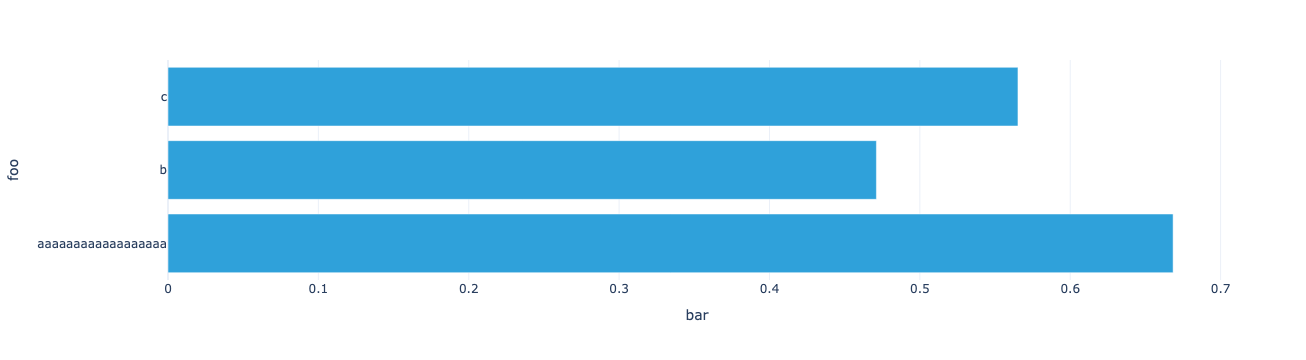

In [155]:
#|hide
plotly_dataarray(U1.array)

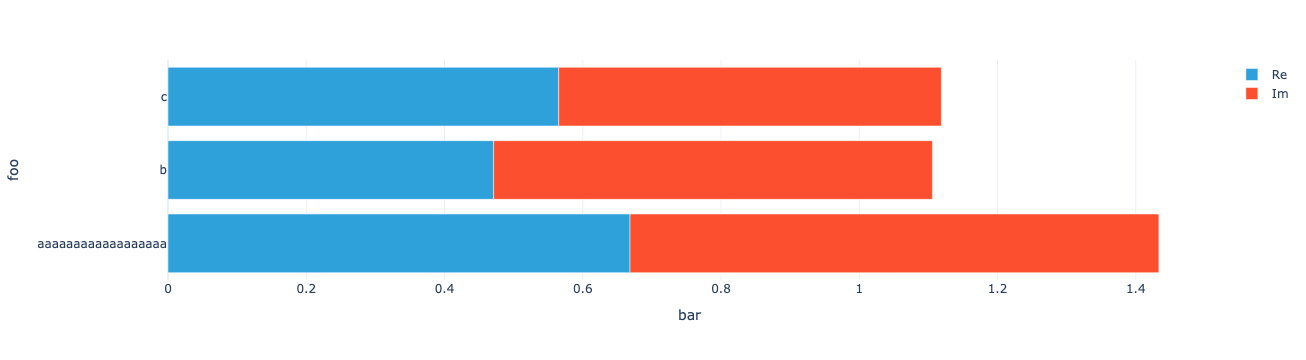

In [156]:
#|hide
plotly_dataarray(U1.array + U2.array)

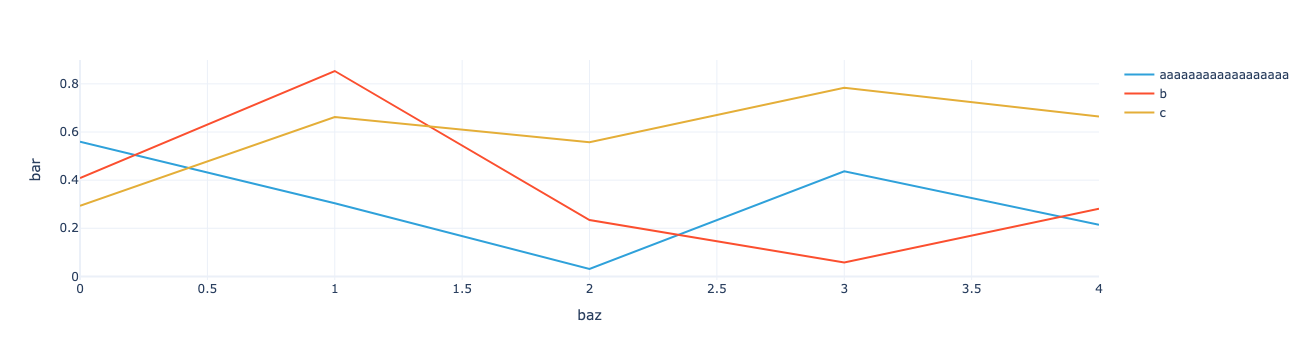

In [157]:
#|hide
plotly_dataarray(U3.array)

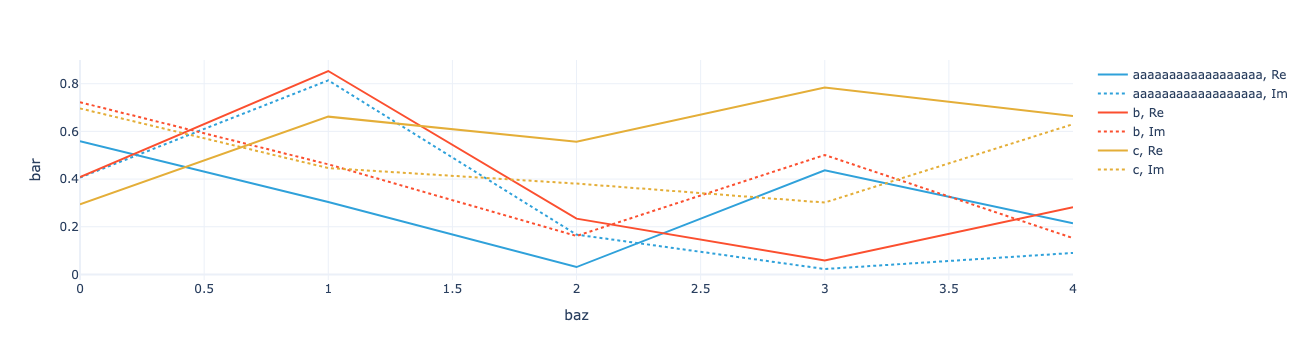

In [158]:
#|hide
plotly_dataarray(U3.array + U4.array)

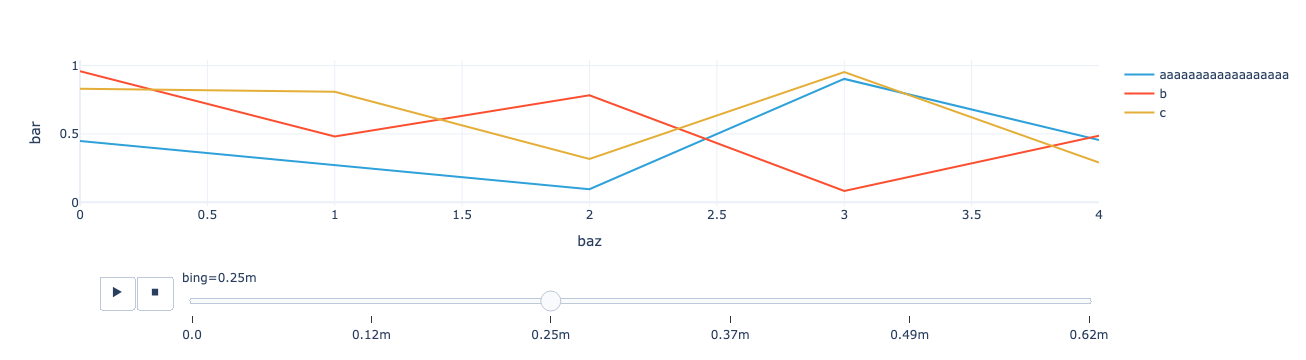

In [159]:
#|hide
plotly_dataarray(U5.array)

### visualize -

In [160]:
#| export
## Could put plotting hints in the attrs of the coordinates inside the model
@patch
@delegates(plotly_dataarray)
def visualize(self:XarrayVectorArray, **kwargs):
    """Visualize the data contained in the `XarrayVectorArray`.
    Put the first dimension with numerical coordinates on the x axis, and include a scrubber if there is a second numerical dimension.
    Atomic velocity is prioritized to be on the x axis, time is prioritized to be on the scrubber.
    Put categorical dimensions in the legend. If the data are complex, add the real and imaginary parts as a categorical dimension.
    If there are no numerical dimensions, plot the categorical dimension(s) as a horizontal bar plot.
    """
    return plotly_dataarray(self.array, **kwargs)

In [161]:
space = XarrayVectorSpace(coords={'foo': ['aaaaaaaaaaaaaaaaaa', 'b', 'c']})
U1 = space.random(name='bar')
U2 = 1j * space.random(name='bar')
U3 = space.random({'baz': np.arange(5)}, name='bar')
U4 = 1j * space.random({'baz': np.arange(5)}, name='bar')
U5 = space.random({'baz': np.arange(5), 'bing': .000123456 * np.linspace(0, 5, 6)}, name='bar')

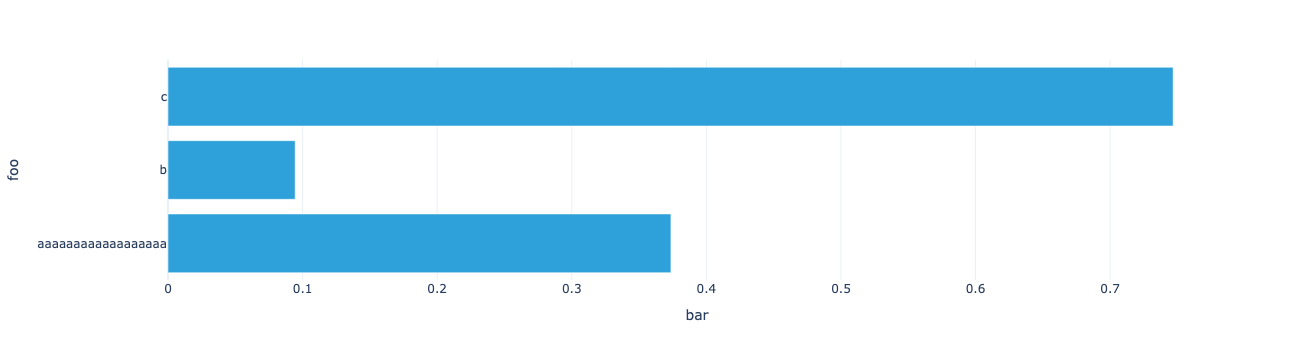

In [162]:
U1.visualize()

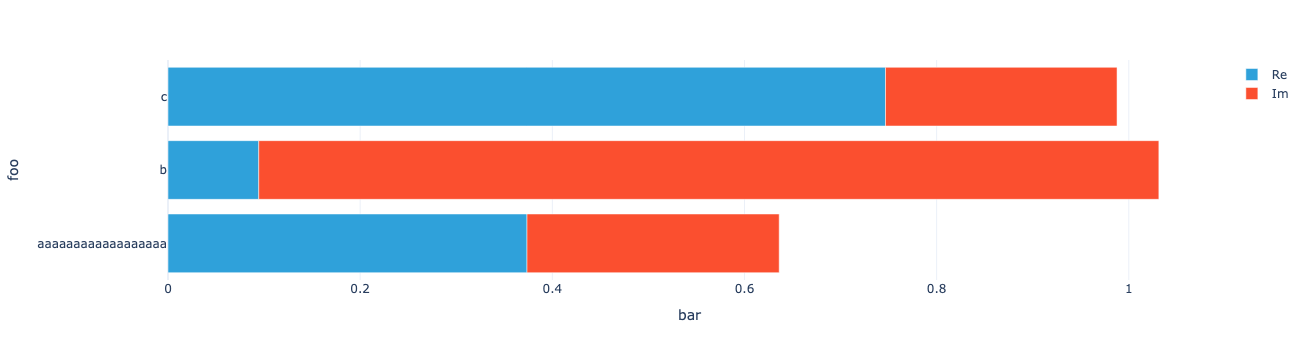

In [163]:
(U1 + U2).visualize()

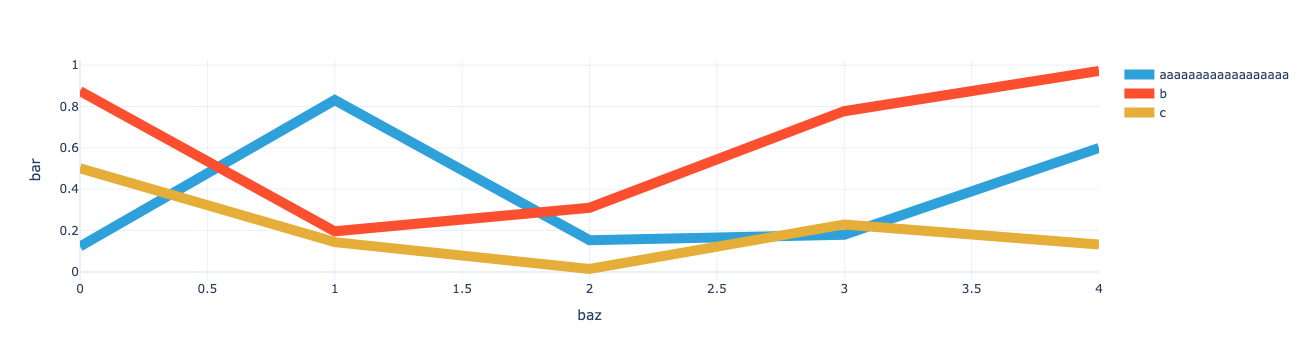

In [164]:
U3.visualize(line_width=10)

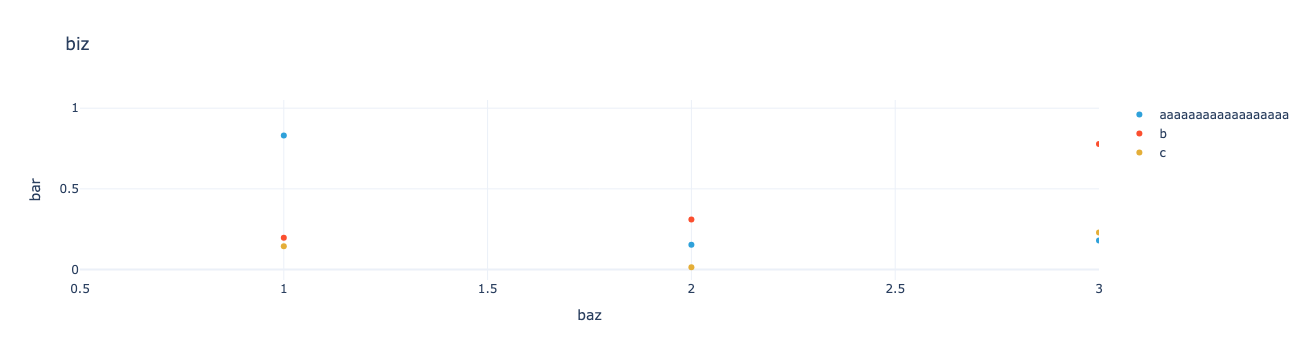

In [165]:
U3.visualize(title='biz', markers=True, xaxis_range=(.5, 3), line_width=0)

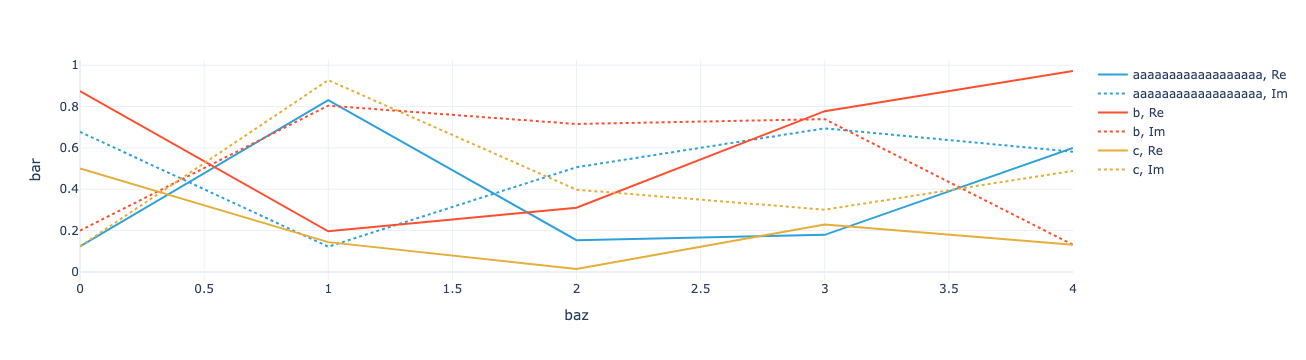

In [166]:
(U3 + U4).visualize()

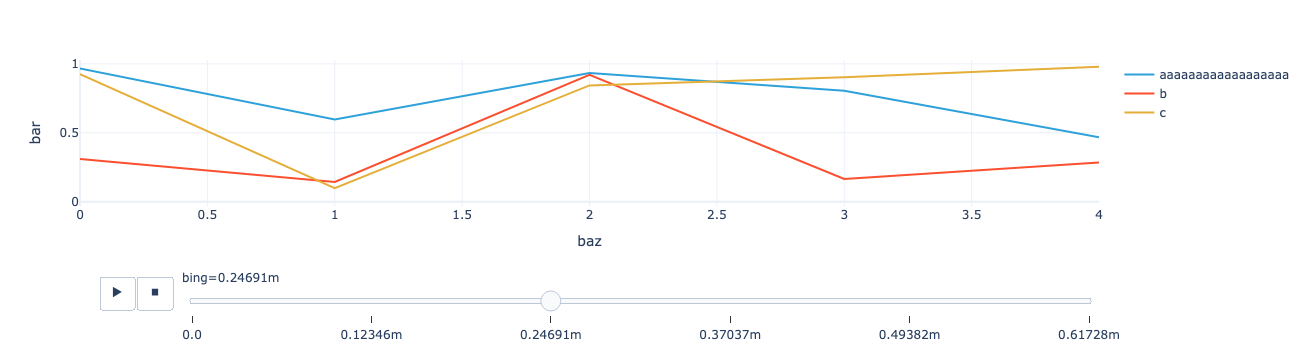

In [167]:
U5.visualize(slider_label_precision=5)

## Export -

In [168]:
#| hide
import nbdev; nbdev.nbdev_export()

In [169]:
#|hide
# #| export
# def _sort_varables(vars, head=set(), tail=set()):
#     vars = set(vars)
#     return (
#         list(set.intersection(vars, head)) 
#         + list(vars - head - tail)
#         + list(set.intersection(vars, tail))
#     )

In [170]:
#|hide
# #| export
# def _apply_opts(obj, **opts):
#     """Traverse a holoviews object and apply `opts` to it or any child of it that accepts them."""
#     if hasattr(obj, 'opts'): obj = obj.opts(**opts)
#     if hasattr(obj, 'object') and hasattr(obj.object, 'opts'): _apply_opts(obj.object, **opts)
#     if hasattr(obj, 'objects'):
#         for o in obj.objects:
#             _apply_opts(o, **opts)

In [171]:
#|hide
# #| export
# def _plotly_trim_legend_label(plot, element):
#     plot.state['data'][0]['name'] = ', '.join(s.split(': ')[1] for s in plot.state['data'][0]['name'].split(', '))

In [172]:
#|hide
# import panel as pn
# pn.extension('plotly')
# import holoviews as hv
# import hvplot.xarray
# hvplot.extension('plotly')

# #|export
# def hvplot_dataarray(array:DataArray, embed=False, scrubber_initial_position=.35, **kwargs):
#     """Visualize the data contained in the `XarrayVectorArray`.
#     Put the first dimension with numerical coordinates on the x axis, and include a scrubber if there is a second numerical dimension. 
#     Put categorical dimensions in the legend. If the data are complex, add the real and imaginary parts as a categorical dimension.
#     If there are no numerical dimensions, plot the categorical dimension(s) as a horizontal bar plot.
#     """
#     array = array.copy()
#     if np.any(np.iscomplex(array)): array = _reim(array)
#     if array.name is None: array = array.rename('Value')
#     default = {}
#     hooks = []
#     if _categorical_dims(array):
#         if array.ndim == 1: 
#             return pn.panel(
#                 array.hvplot.barh(x=_categorical_dims(array)[0], y=array.name).opts(hooks=[_plotly_automargin] + hooks)
#             )
#         default.update(by=_categorical_dims(array))
#     else:
#         default.update(legend=False)
#     if len(_numerical_dims(array)) > 0: default.update(x=first(_numerical_dims(array)))
#     if len(_numerical_dims(array)) > 1: default.update(widget_type='scrubber', widget_location='bottom')
#     else: default.update(title="")
#     ymin, ymax = array.min(), array.max()
#     padding = .05
#     default.update(ylim=(ymin - padding * (ymax - ymin), ymax + padding * (ymax - ymin)))
#     plot = array.hvplot(**default | kwargs)
#     if len(_numerical_dims(array)) > 1: _set_scrubber_fractional_value(plot, scrubber_initial_position)

#     def _plotly_trim_legend_label(plot, element):
#         plot.state['data'][0]['name'] = _delete(plot.state['data'][0]['name'], [s + ': ' for s in default['by']])
        
#     _apply_opts(plot, hooks=[_plotly_trim_legend_label] + hooks)
#     if embed: return pn.panel(plot).embed()
#     return pn.panel(plot)

# #| export
# ## Could put plotting hints in the attrs of the coordinates inside the model
# @patch
# @delegates(visualize_dataarray)
# def visualize(self:XarrayVectorArray, **kwargs):
#     """Visualize the data contained in the `XarrayVectorArray`.
#     Put the first dimension with numerical coordinates on the x axis, and include a scrubber if there is a second numerical dimension. 
#     Put categorical dimensions in the legend. If the data are complex, add the real and imaginary parts as a categorical dimension.
#     If there are no numerical dimensions, plot the categorical dimension(s) as a horizontal bar plot.
#     """
#     return hvplot_dataarray(self.array, **kwargs)

# space = XarrayVectorSpace(coords={'foo': ['aaaaaaaaaaaaaaaaaa', 'b', 'c']})

# space.random(name='bar').visualize()

# space.random({'baz': np.arange(5)}, name='bar').visualize()

# space.random({'baz': np.arange(5)}, name='bar').visualize(title='biz', kind='scatter')

# (
#     space.random({'baz': np.arange(5)}, name='bar') 
#     + 1j * space.random({'baz': np.arange(5)}, name='bar')
# ).visualize()

# space.random({'baz': np.arange(5), 'bing': np.linspace(0, 5, 6)}, name='bar').visualize()